# RL - Chapter 2 - Multi-armed Bandits


In [16]:
from toc import generate_toc

path = 'ch_2_Bandits.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 2 - Multi-armed Bandits](#rl-chapter-2-multi-armed-bandits)
  - [Stationary K-armed Bandit Problem](#stationary-k-armed-bandit-problem)
    - [Create K-armed Bandit Class](#create-k-armed-bandit-class)
    - [Test 1](#test-1)
    - [Test2: Run one problem, 1000 steps](#test2-run-one-problem-1000-steps)
    - [Run 1000 problems, each 1000 steps with different epsilons](#run-1000-problems-each-1000-steps-with-different-epsilons)
  - [Constant step size](#constant-step-size)
  - [Upper-Confidence-Bound Action Selection](#upper-confidence-bound-action-selection)
  - [Gradient Bandit Algorithms](#gradient-bandit-algorithms)

## Stationary K-armed Bandit Problem


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# set seed for reproducibility
np.random.seed(42)

In [3]:
n_problems = 1000
n_steps = 1000

### Create K-armed Bandit Class


In [4]:
# create problem class
class BanditProblem:
    def __init__(self, k: int = 10):
        self.k = k
        self.q_true = np.random.normal(0, 1, k)  # true action values

In [5]:
# define k-armed bandit class
class KArmedBandit:
    def __init__(self, k=10, epsilon=0.1, method='epsilon-greedy', use_random_walk=False):
        self.method = method
        self.k = k
        self.q_true = np.random.normal(0, 1, k)     # true action values
        self.q_estimation = np.zeros(k)             # estimated action values
        self.action_count = np.zeros(k)             # count of actions taken
        self.epsilon = epsilon          # exploration rate
        self.c_ucb = 2                  # UCB exploration parameter
        self.alpha = 0.1                # step size for updating estimates using constant step size method
        self.use_random_walk = use_random_walk

    def act(self) -> int:
        ''' returns the action index based on epsilon-greedy strategy '''
        if np.random.rand() < self.epsilon:  # explore with probability epsilon
            return np.random.randint(self.k)
        else:  # exploit
            return self.act_eps_greedy()

    def act_eps_greedy(self) -> int:
        ''' epsilon-greedy action selection based on estimated action values and UCB if enabled'''
        if self.method == 'UCB':
            ucb_values = np.sqrt(np.log(np.sum(self.action_count) + 1) / (self.action_count + 1e-5))
            return np.argmax(self.q_estimation + self.c_ucb * ucb_values)
        else:
            return np.argmax(self.q_estimation)

    def step(self, action: int) -> float:
        ''' returns the reward for the given action and updates the estimated action value '''
        if self.use_random_walk:
            # simulate non-stationary problem by adding random walk to true action values
            self.q_true += np.random.normal(0, 0.01, self.k)
        reward = np.random.normal(self.q_true[action], 1)  # reward with noise
        self.action_count[action] += 1

        if self.method != 'constant-step':
            # update estimated action value using incremental formula
            self.q_estimation[action] += (reward - self.q_estimation[action]) / self.action_count[action]
        else:
            # update estimated action value using constant step size method
            self.q_estimation[action] += self.alpha * (reward - self.q_estimation[action])
        return reward

    def run_episode(self, n_steps: int = 1000):
        ''' runs an episode of n_steps and returns the rewards and actions taken '''
        rewards = []
        actions = []
        for _ in range(n_steps):
            action = self.act()
            reward = self.step(action)
            rewards.append(reward)
            actions.append(action)
        return rewards, actions

### Test 1


In [6]:
# create an instance of the k-armed bandit
bandit = KArmedBandit(k=10, epsilon=0.1, method='epsilon-greedy')
# print with 2 decimal places
np.set_printoptions(precision=2)
print("True action values:\n", bandit.q_true)

True action values:
 [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]


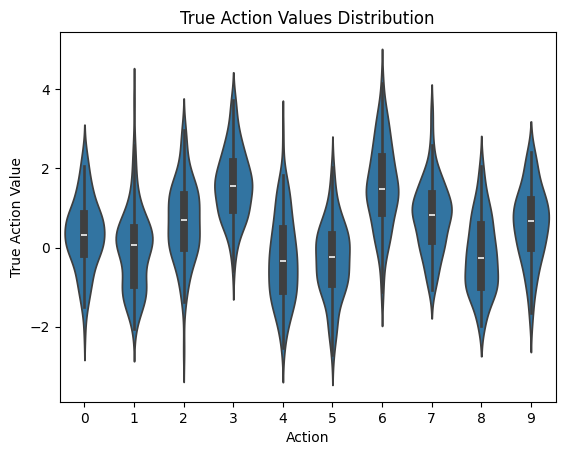

In [7]:
# plot violin plot of action value q_true only
# should have k violins, each representing the distribution of the true action values
def plot_violin(q_true):
    # Create samples from each action's distribution
    n_samples = 100
    data = []
    for action in range(len(q_true)):
        samples = np.random.normal(q_true[action], 1, n_samples)
        for sample in samples:
            data.append({'action': action, 'value': sample})

    df = pd.DataFrame(data)
    sns.violinplot(data=df, x='action', y='value')
    plt.title('True Action Values Distribution')
    plt.xlabel('Action')
    plt.ylabel('True Action Value')
    plt.show()


# plot the true action values
plot_violin(bandit.q_true)

### Test2: Run one problem, 1000 steps


In [8]:
# run 1000 steps and plot the estimated action values
rewards, actions = bandit.run_episode(n_steps)

# print final estimated and real action values
print("Estimated action values:\n", bandit.q_estimation)
print("True action values:\n", bandit.q_true)

Estimated action values:
 [ 0.59  0.44  1.18  1.57 -0.74 -0.3   1.55  0.72 -1.34  0.99]
True action values:
 [ 0.5  -0.14  0.65  1.52 -0.23 -0.23  1.58  0.77 -0.47  0.54]


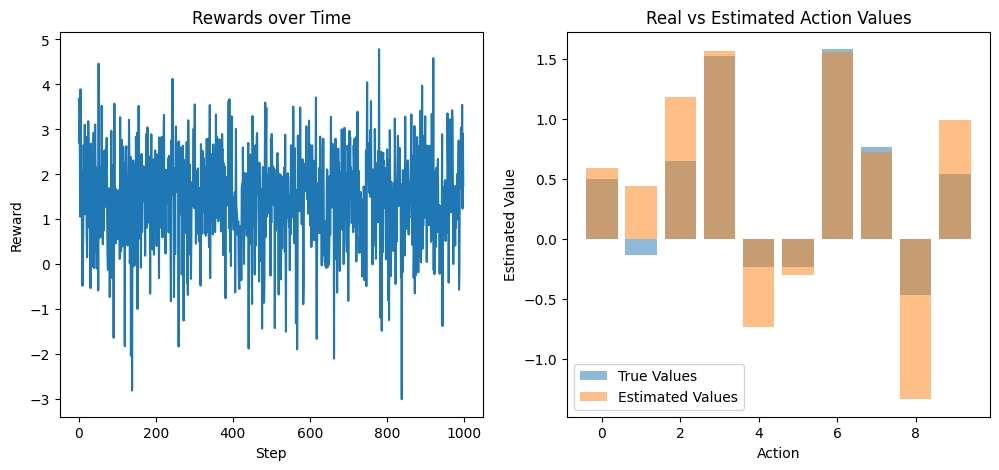

In [9]:
# plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(rewards)
plt.title('Rewards over Time')
plt.xlabel('Step')
plt.ylabel('Reward')
plt.subplot(1, 2, 2)
plt.bar(range(bandit.k), bandit.q_true, alpha=0.5, label='True Values')
plt.bar(range(bandit.k), bandit.q_estimation, alpha=0.5, label='Estimated Values')
plt.legend()
plt.title('Real vs Estimated Action Values')
plt.xlabel('Action')
plt.ylabel('Estimated Value')
plt.show()

### Run 1000 problems, each 1000 steps with different epsilons


In [10]:
# run 1000 steps for each bandit problem, then plot average rewards over time
epsilons = [0.1, 0.01, 0]  # different exploration rates
n_eps = len(epsilons)
all_rewards = np.zeros((n_eps, n_problems, n_steps))
optimal_actions = np.zeros((n_eps, n_problems, n_steps), dtype=bool)

for e, epsilon in enumerate(epsilons):
    for i in range(n_problems):
        bandit = KArmedBandit(k=10, epsilon=epsilon, method='epsilon-greedy')
        rewards, actions = bandit.run_episode(n_steps)
        optimal_actions[e, i] = (actions == np.argmax(bandit.q_true))
        all_rewards[e, i] = rewards

# mean over bandits for each epsilon
mean_rewards = all_rewards.mean(axis=1)
mean_optimal_actions = optimal_actions.mean(axis=1)

# save results in a dictionary
sol_eps_greedy = {'rewards': rewards,
                  'optimal_actions': optimal_actions,
                  'mean_rewards': mean_rewards,
                  'mean_optimal_actions': mean_optimal_actions}

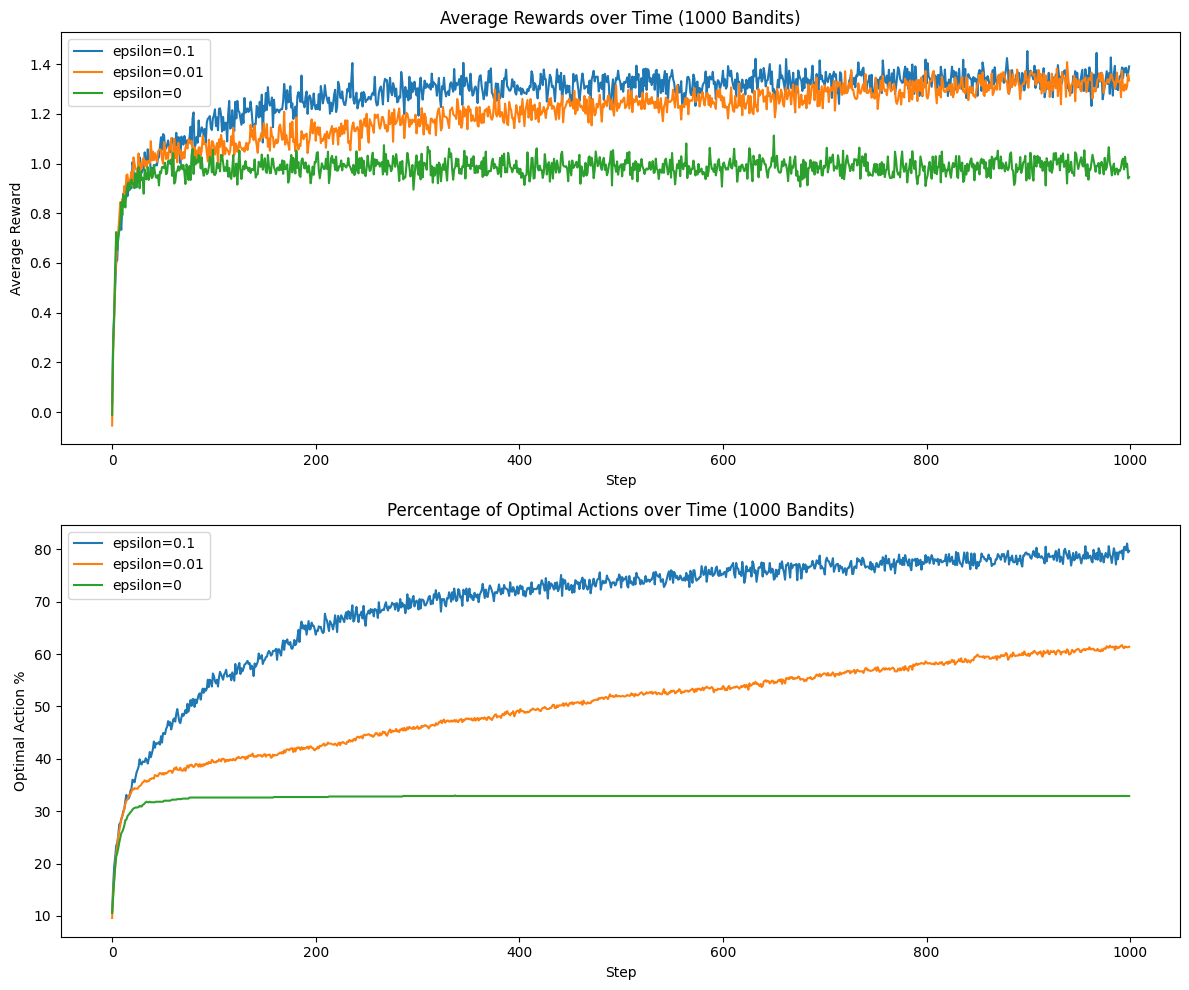

In [11]:
# plot average rewards over time for each epsilon
fig, ax = plt.subplots(2, 1, figsize=(12, 10), tight_layout=True)
for e, epsilon in enumerate(epsilons):
    average_rewards = mean_rewards[e]
    ax[0].plot(average_rewards, label=f'epsilon={epsilon}')
ax[0].set_title(f'Average Rewards over Time ({n_problems} Bandits)')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Average Reward')
ax[0].legend()

# percentage of optimal actions over time
for e, epsilon in enumerate(epsilons):
    optimal_action_percentage = mean_optimal_actions[e] * 100
    ax[1].plot(optimal_action_percentage, label=f'epsilon={epsilon}')
ax[1].set_title(f'Percentage of Optimal Actions over Time ({n_problems} Bandits)')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Optimal Action %')
ax[1].legend()
plt.show()

## Constant step size


In [12]:
# # compate constant step size with sample-average method for epsilon-greedy action selection
methods = ['epsilon-greedy', 'constant-step']
n_methods = len(methods)
all_rewards = np.zeros((n_methods, n_problems, n_steps))
optimal_actions = np.zeros((n_methods, n_problems, n_steps), dtype=bool)
for u, method in enumerate(methods):
    for i in range(n_problems):
        bandit = KArmedBandit(k=10, epsilon=0.1, method=method, use_random_walk=True)
        rewards, actions = bandit.run_episode(n_steps)
        optimal_actions[u, i] = (actions == np.argmax(bandit.q_true))
        all_rewards[u, i] = rewards

# mean over bandits for each method
mean_rewards = all_rewards.mean(axis=1)
mean_optimal_actions = optimal_actions.mean(axis=1)

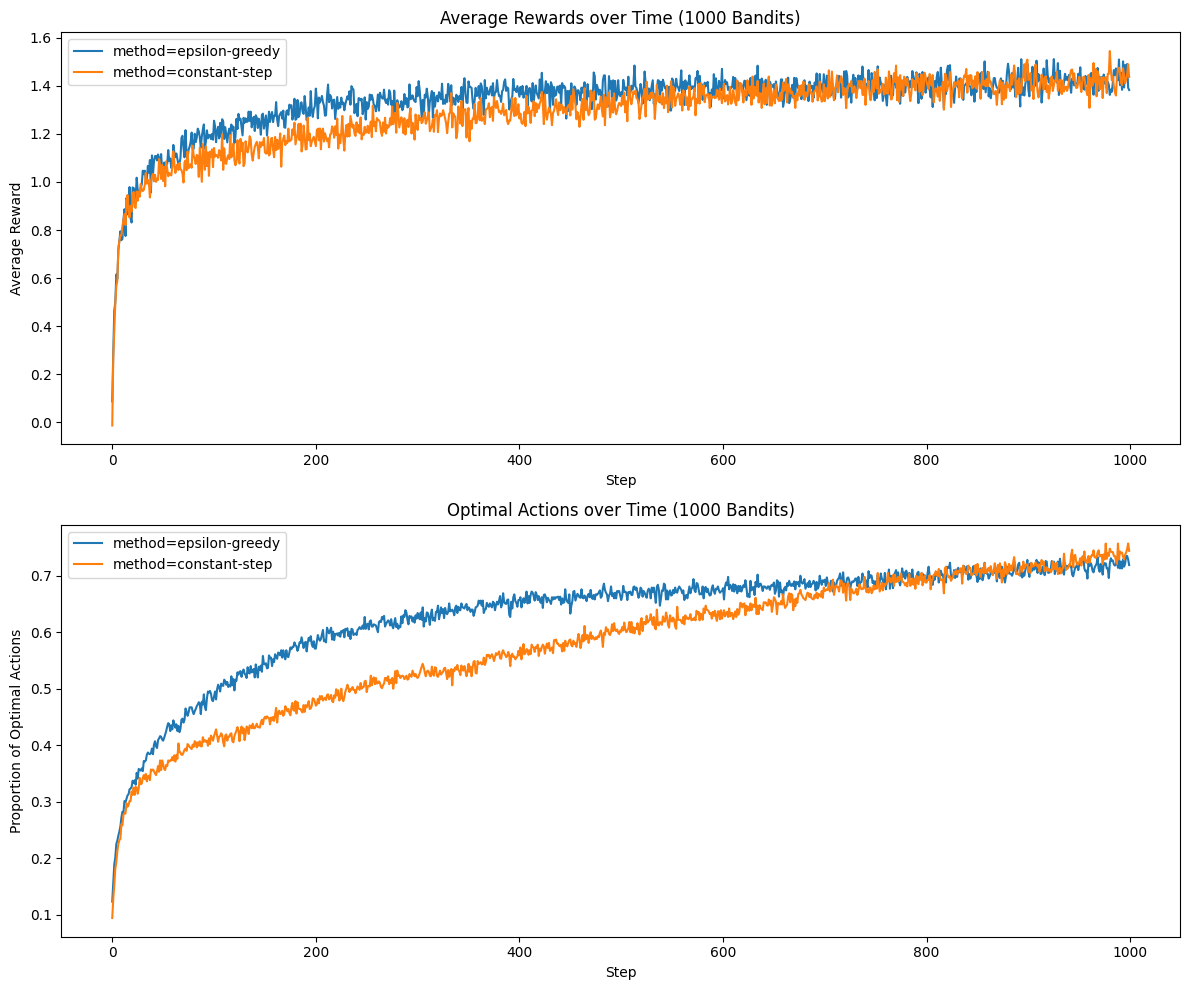

In [13]:
# plot the rewards over time for each c_baseline setting
fig, ax = plt.subplots(2, 1, figsize=(12, 10), tight_layout=True)
for u, method in enumerate(methods):
    average_rewards = mean_rewards[u]
    ax[0].plot(average_rewards, label=f'method={method}')
ax[0].set_title(f'Average Rewards over Time ({n_problems} Bandits)')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Average Reward')
ax[0].legend()

# plot the optimal actions over time for each method
for u, method in enumerate(methods):
    average_optimal_actions = mean_optimal_actions[u]
    ax[1].plot(average_optimal_actions, label=f'method={method}')
ax[1].set_title(f'Optimal Actions over Time ({n_problems} Bandits)')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Proportion of Optimal Actions')
ax[1].legend()
plt.show()

## Upper-Confidence-Bound Action Selection


In [14]:
# create 1000 bandits and run 1000 steps for e=0.1 and with ucb = [true, false], then plot average rewards over time
epsilons = [0.1]
methods = ['epsilon-greedy', 'UCB']
n_methods = len(methods)
all_rewards = np.zeros((n_methods, n_problems, n_steps))
optimal_actions = np.zeros((n_methods, n_problems, n_steps), dtype=bool)
for m, method in enumerate(methods):
    for i in range(n_problems):
        eps = 0 if method == 'UCB' else 0.1
        bandit = KArmedBandit(k=10, epsilon=eps, method=method)
        rewards, actions = bandit.run_episode()
        optimal_actions[m, i] = (actions == np.argmax(bandit.q_true))
        all_rewards[m, i] = rewards

# mean over bandits for each ucb setting
mean_rewards = all_rewards.mean(axis=1)
mean_optimal_actions = optimal_actions.mean(axis=1)

# save results in a dictionary
sol_ucb = {'rewards': rewards,
           'optimal_actions': optimal_actions,
           'mean_rewards': mean_rewards,
           'mean_optimal_actions': mean_optimal_actions}

KeyboardInterrupt: 

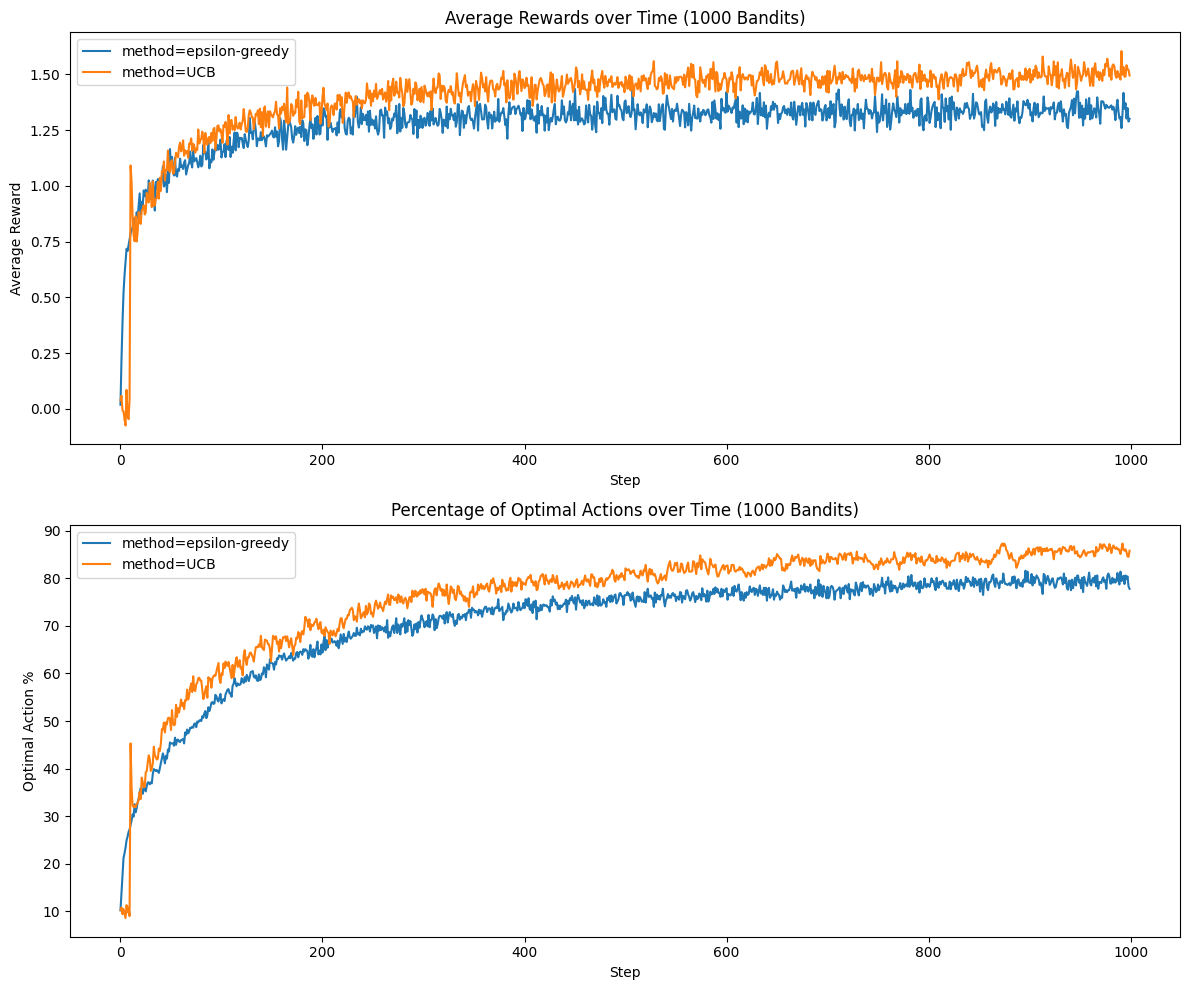

In [ ]:
# plot the rewards over timefor each ucb setting
fig, ax = plt.subplots(2, 1, figsize=(12, 10), tight_layout=True)
for u, method in enumerate(methods):
    average_rewards = mean_rewards[u]
    ax[0].plot(average_rewards, label=f'method={method}')
ax[0].set_title(f'Average Rewards over Time ({n_problems} Bandits)')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Average Reward')
ax[0].legend()
# percentage of optimal actions over time
for u, method in enumerate(methods):
    optimal_action_percentage = mean_optimal_actions[u] * 100
    ax[1].plot(optimal_action_percentage, label=f'method={method}')
ax[1].set_title(f'Percentage of Optimal Actions over Time ({n_problems} Bandits)')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Optimal Action %')
ax[1].legend()
plt.show()

## Gradient Bandit Algorithms


In [ ]:
# Gradient Bandit Algorithm
class GradientBandit:
    def __init__(self, k=10, alpha=0.1, c_baseline=1):
        self.k = k
        self.q_true = np.random.normal(4, 1, k)  # true action values
        self.H = np.zeros(k)  # action preferences
        self.action_count = np.zeros(k)  # count of actions taken
        self.alpha = alpha  # step size parameter
        self.c_baseline = c_baseline  # baseline for the gradient update
        self.r_mean = 0  # average reward

    def act(self) -> int:
        ''' returns the action index based on softmax probabilities of preferences'''
        exp_H = np.exp(self.H)  # for numerical stability
        action_probabilities = exp_H / np.sum(exp_H)
        return np.random.choice(self.k, p=action_probabilities)

    def step(self, action: int) -> float:
        ''' returns the reward for the given action and updates the preferences'''
        # reward with noise
        reward = np.random.normal(self.q_true[action], 1)
        self.action_count[action] += 1
        # update average reward
        self.r_mean += (reward - self.r_mean) / np.sum(self.action_count)

        # update preferences using gradient ascent
        exp_H = np.exp(self.H)
        action_probabilities = exp_H / np.sum(exp_H)
        self.H += self.alpha * (reward - self.c_baseline * self.r_mean) * (np.eye(self.k)[action] - action_probabilities)
        return reward

    def run_episode(self, n_steps: int):
        rewards = []
        actions = []
        for _ in range(n_steps):
            action = self.act()
            reward = self.step(action)
            rewards.append(reward)
            actions.append(action)
        return rewards, actions

In [ ]:
# run gradient bandits on all bandit problems
c_baselines = [1, 0]  # with and without baseline
n_c = len(c_baselines)
all_rewards = np.zeros((n_c, n_problems, n_steps))
optimal_actions = np.zeros((n_c, n_problems, n_steps), dtype=bool)
for c, c_baseline in enumerate(c_baselines):
    for i in range(n_problems):
        bandit = GradientBandit(k=10, alpha=0.1, c_baseline=c_baseline)
        rewards, actions = bandit.run_episode(n_steps)
        optimal_actions[c, i] = (actions == np.argmax(bandit.q_true))
        all_rewards[c, i] = rewards

# mean over bandits for each c_baseline setting
mean_rewards = all_rewards.mean(axis=1)
mean_optimal_actions = optimal_actions.mean(axis=1)

# save results in a dictionary
sol_gradient = {'rewards': rewards,
                'optimal_actions': optimal_actions,
                'mean_rewards': mean_rewards,
                'mean_optimal_actions': mean_optimal_actions}

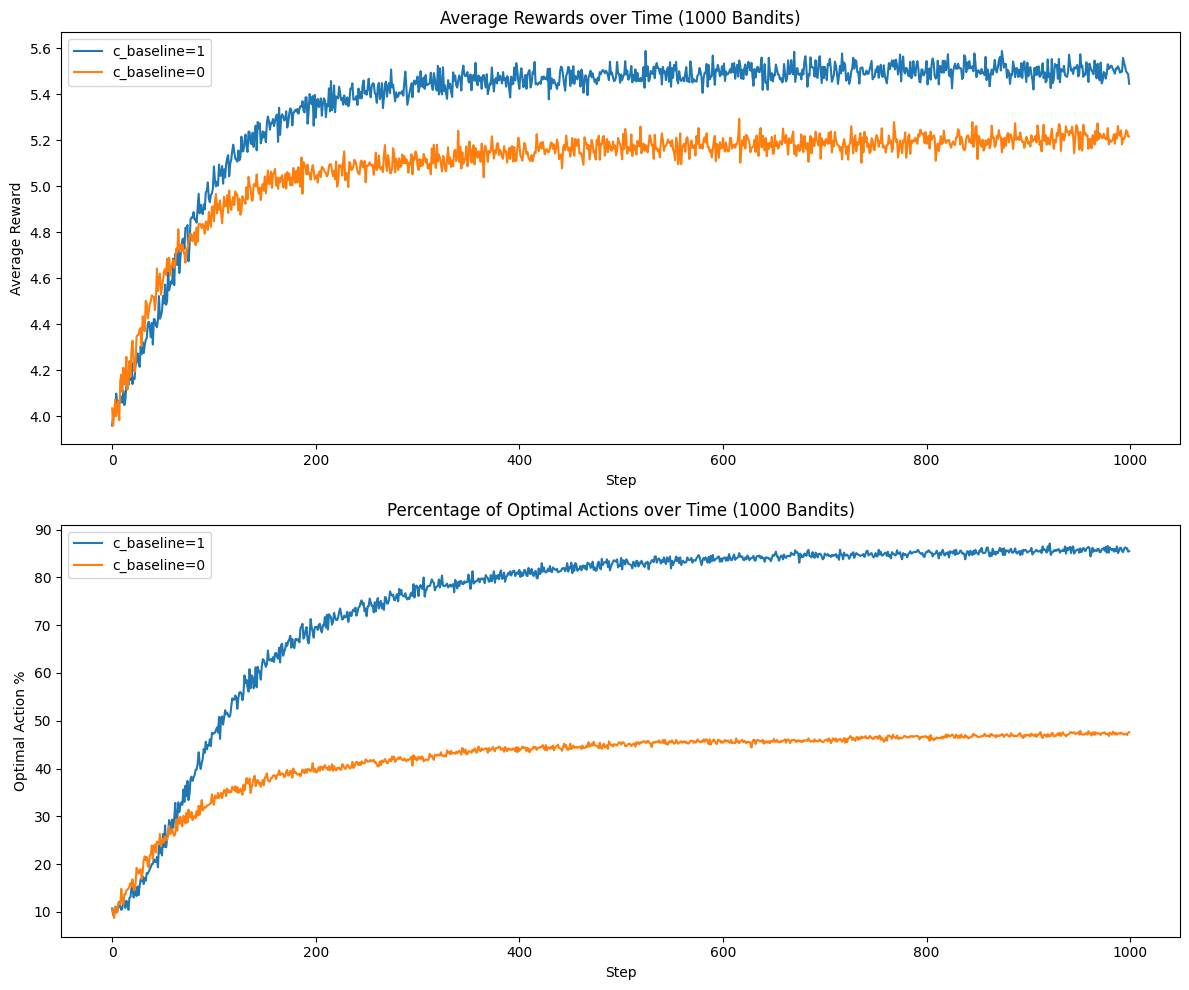

In [ ]:
# plot the rewards over time for each c_baseline setting
fig, ax = plt.subplots(2, 1, figsize=(12, 10), tight_layout=True)
for c, c_baseline in enumerate(c_baselines):
    average_rewards = mean_rewards[c]
    ax[0].plot(average_rewards, label=f'c_baseline={c_baseline}')
ax[0].set_title(f'Average Rewards over Time ({n_problems} Bandits)')
ax[0].set_xlabel('Step')
ax[0].set_ylabel('Average Reward')
ax[0].legend()
# percentage of optimal actions over time
for c, c_baseline in enumerate(c_baselines):
    optimal_action_percentage = mean_optimal_actions[c] * 100
    ax[1].plot(optimal_action_percentage, label=f'c_baseline={c_baseline}')
ax[1].set_title(f'Percentage of Optimal Actions over Time ({n_problems} Bandits)')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Optimal Action %')
ax[1].legend()
plt.show()